In [1]:
import numpy as np
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import LeaveOneOut

In [2]:
df = pd.read_csv('sensores.csv')

In [3]:
df

,Atributo_1,Atributo_2,Atributo_3,Atributo_4,Atributo_5,Atributo_6,Atributo_7,Atributo_8,target
0,0.496714,-0.138264,0.647689,1.523030,-0.234153,-0.234137,1.579213,0.767435,1
1,-0.469474,0.542560,-0.463418,-0.465730,0.241962,-1.913280,-1.724918,-0.562288,0
2,-1.012831,0.314247,-0.908024,-1.412304,1.465649,-0.225776,0.067528,-1.424748,1
3,-0.544383,0.110923,-1.150994,0.375698,-0.600639,-0.291694,-0.601707,1.852278,1
4,-0.013497,-1.057711,0.822545,-1.220844,0.208864,-1.959670,-1.328186,0.196861,0
...,...,...,...,...,...,...,...,...,...
995,-0.630458,1.637082,-0.780144,0.735269,-0.559164,-0.460307,1.030250,-0.380037,0
996,-0.404795,1.132805,1.597397,0.644690,-0.654770,-0.510608,0.079915,0.320930,0
997,-0.987866,0.723038,0.085513,-1.715708,-0.928926,-0.504129,-0.072858,1.889279,1
998,0.238171,-0.840772,0.220631,-0.352088,0.324758,0.580568,1.209231,-0.024286,0


In [4]:
scaler = StandardScaler()

In [5]:
dados_padronizados = scaler.fit_transform(df.iloc[:, :-1])

In [6]:
dados_padronizados

array([[ 0.50005258, -0.1079961 ,  0.69137884, ..., -0.2174599 ,
         1.54266063,  0.72124761],
       [-0.46570918,  0.57203085, -0.43181987, ..., -1.87318757,
        -1.65304186, -0.57797922],
       [-1.00882591,  0.34398554, -0.88126503, ..., -0.20921584,
         0.08058337, -1.42066048],
       ...,
       [-0.98387173,  0.75229737,  0.12308532, ..., -0.48368659,
        -0.05519563,  1.81736367],
       [ 0.24162393, -0.8096809 ,  0.25967332, ...,  0.5858837 ,
         1.18481977, -0.05231653],
       [ 1.6417944 ,  0.93706544, -0.67849748, ..., -0.81006669,
         1.61394232,  2.00153949]], shape=(1000, 8))

In [7]:
pca = PCA()

In [8]:
dados_pca = pca.fit_transform(dados_padronizados)

In [9]:
dados_pca

array([[-1.00191225, -1.08652608,  0.70735925, ..., -0.04277897,
        -0.46090549,  1.41207008],
       [ 1.56243282,  0.39897564, -1.94944629, ..., -0.79636812,
        -0.20001234, -0.42570692],
       [ 1.86313495,  0.5654041 , -0.05326957, ...,  0.57754214,
        -0.87677555, -0.399163  ],
       ...,
       [ 1.17332664, -0.20633089,  0.01206161, ...,  1.1537082 ,
         0.72878039, -1.49490119],
       [-0.52775583,  0.30376184,  1.25823946, ...,  0.48839252,
        -0.70099184,  0.11597958],
       [ 0.18891   , -1.76142352,  1.47240733, ..., -1.55164509,
         0.62971354,  2.29420302]], shape=(1000, 8))

In [10]:
explained_variance = pca.explained_variance_ratio_
explained_variance

array([0.1409125 , 0.13238103, 0.1307604 , 0.12946748, 0.12256327,
       0.12096314, 0.11395785, 0.10899434])

In [11]:
# Ajustar o range para começar de 1
componentes = range(1, len(explained_variance) + 1)

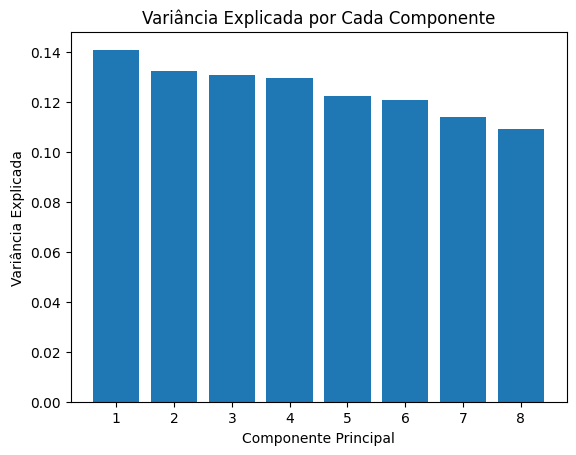

In [12]:
plt.bar(componentes, explained_variance)
plt.xticks(componentes)
plt.xlabel('Componente Principal')
plt.ylabel('Variância Explicada')
plt.title('Variância Explicada por Cada Componente')
plt.show()

In [13]:
componentes = pd.DataFrame(pca.components_, 
                           columns = df.iloc[:, :-1].columns, 
                           index = [f'PC-{i}' for i in range(1, 9)])

In [14]:
componentes

,Atributo_1,Atributo_2,Atributo_3,Atributo_4,Atributo_5,Atributo_6,Atributo_7,Atributo_8
PC-1,-0.196388,0.468139,-0.405046,-0.417747,0.436951,-0.448249,0.010965,0.108297
PC-2,0.275254,-0.406774,0.350551,-0.470875,0.485621,0.042320,-0.420036,0.010603
PC-3,0.389133,-0.176295,-0.305869,-0.250275,0.137979,0.371768,0.654928,0.274085
PC-4,-0.542503,-0.297805,-0.009931,0.296110,0.291527,0.101594,-0.043470,0.657285
PC-5,0.263291,0.017466,0.357604,-0.145364,-0.401602,-0.537062,0.112864,0.564716
PC-6,-0.446916,0.310198,0.585621,-0.388296,-0.030855,0.316280,0.325487,-0.058223
PC-7,0.265614,0.548444,-0.058386,0.008642,-0.092213,0.495751,-0.462134,0.396654
PC-8,0.316742,0.313520,0.380994,0.530533,0.546333,-0.120463,0.245726,-0.037217


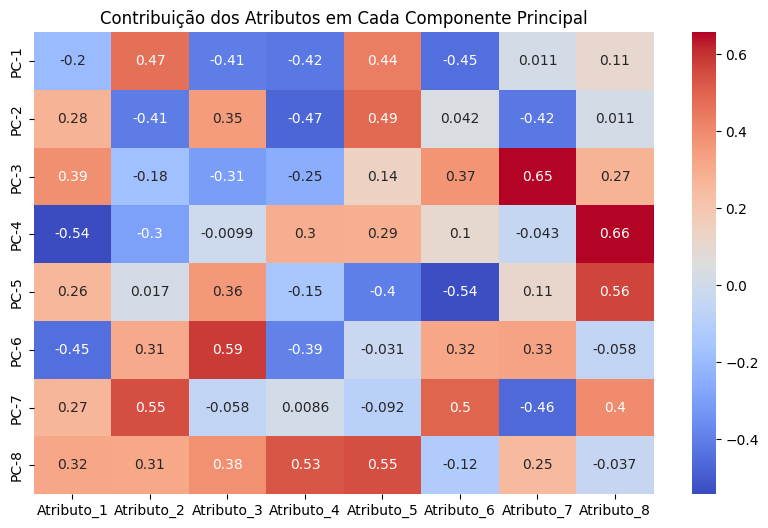

In [15]:
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.heatmap(componentes, cmap="coolwarm", annot=True)
plt.title("Contribuição dos Atributos em Cada Componente Principal")
plt.show()

In [16]:
scores = []

# Loop sobre o número de componentes do PCA de 1 a 8
for i in range(1, 9):
    
    # Cria um objeto PCA com i componentes
    pca = PCA(n_components = i)
    
    # Ajusta o PCA aos dados escalonados e transforma os dados
    pca_data = pca.fit_transform(dados_padronizados)
    
    # Cria um objeto de regressão logística
    lr = LogisticRegression()
    
    # Avalia a regressão logística usando validação cruzada e calcula a média das pontuações
    score = cross_val_score(lr, pca_data, df['target'], cv = 5).mean()
    
    # Adiciona a média das pontuações à lista de pontuações
    scores.append(score)

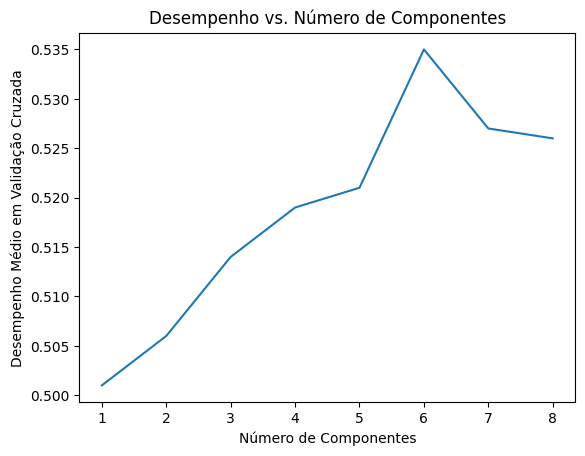

In [17]:
plt.plot(range(1, 9), scores)
plt.xlabel('Número de Componentes')
plt.ylabel('Desempenho Médio em Validação Cruzada')
plt.title('Desempenho vs. Número de Componentes')
plt.show()

In [18]:
pca_final = PCA(n_components = 6)
pca_data_final = pca_final.fit_transform(dados_padronizados)
modelo_lr_final = LogisticRegression()
modelo_lr_final.fit(pca_data_final, df['target'])

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [19]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = modelo_lr_final.predict(pca_data_final)
print(classification_report(df['target'], y_pred))


              precision    recall  f1-score   support

           0       0.55      0.46      0.50       487
           1       0.56      0.65      0.60       513

    accuracy                           0.56      1000
   macro avg       0.56      0.55      0.55      1000
weighted avg       0.56      0.56      0.55      1000



### Métricas por classe

#### Classe 0:
- **Precision (0.55):** Das previsões que o modelo fez como classe 0, 55% estavam corretas.
- **Recall (0.46):** De todos os exemplos que realmente são classe 0, o modelo identificou corretamente 46%.
- **F1-score (0.50):** Média harmônica de precision e recall. Dá uma noção geral do equilíbrio entre os dois.

#### Classe 1:
- **Precision (0.56):** Das previsões que o modelo fez como classe 1, 56% estavam corretas.
- **Recall (0.65):** De todos os exemplos que realmente são classe 1, o modelo acertou 65%.
- **F1-score (0.60):** Melhor que o da classe 0, indicando que o modelo está mais eficiente em prever a classe 1.

---

### Acurácia geral:
- **Accuracy (0.56):** O modelo acertou a classe correta em 56% dos casos.

---

### Médias:
- **Macro avg:** Média simples entre as classes (trata todas igualmente).
- **Weighted avg:** Média ponderada pelo número de amostras de cada classe (leva em conta o desequilíbrio entre elas).

---

### Resumo prático:
- O modelo está um pouco melhor para prever a **classe 1** do que a **classe 0**.
- A **acurácia de 56%** é **ligeiramente melhor que o acaso (50%)**, mas ainda **baixa**.

Possíveis motivos:
- As componentes principais do PCA podem estar perdendo **informação relevante**.
- O problema pode ser **não linear**, e a regressão logística (linear) está **limitada**.
- O modelo pode estar **desbalanceado** ou precisar de **tuning de hiperparâmetros**.

---

